# California Housing Market Segmentation

## Project overview

This case study applies **unsupervised learning** to a sample of California housing data. The aim is to identify groups of observations with similar housing, demographic and economic characteristics and to compare how different clustering approaches affect the segmentation.

**Business-style question:** Can housing observations be grouped into meaningful market segments, and which characteristics distinguish those groups?

**Methods:** descriptive statistics, hierarchical clustering, standardisation, K-Means, ANOVA, silhouette analysis, elbow method and cluster profiling.

### Interpretation note
Different validation methods do not point to exactly the same number of clusters. The notebook therefore treats cluster selection as an exploratory modelling decision rather than claiming one universally optimal solution.


The dataset used in this research, which is known as the California Housing Data, is a modified version of the 1990 US Census.
By analysing this data, stakeholders may identify:

* Indentify Impact on Home pricing: how a home's location, income level, and age influence market pricing and community development.
* The purpose of this research is to give insight into California housing dynamics that will help influence real estate development and urban planning decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage #for dendogram and linkage
from matplotlib.pyplot import figure


In [ ]:
from pathlib import Path

DATA_PATH = Path('../data/california_housing.csv')
data = pd.read_csv(DATA_PATH)
feature_columns = data.columns.tolist()

## Data description
The California Housing Dataset organises key characteristics such as:
* housing median age,
* total number of rooms,
* total number of bedrooms,
* population,
* households,
* median income,
* median house value,
in California.

This complicated data collection has 300 observations spread across 7 numerical qualities and is incredible for having no missing values in any column.

In [ ]:
data.info() #what kind of information do we have from data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  300 non-null    float64
 1   total_rooms         300 non-null    float64
 2   total_bedrooms      300 non-null    float64
 3   population          300 non-null    float64
 4   households          300 non-null    float64
 5   median_income       300 non-null    float64
 6   median_house_value  300 non-null    float64
dtypes: float64(7)
memory usage: 16.5 KB


In [ ]:
print(data.shape)

(300, 7)


## Exploratory analysis

* Average age of housing: The average age of housing is 29, with a standard variation of 12.73 years. The age of homes ranges from 2 to 52 years, with the middle 50% falling between 19 and 38.
* Total number of rooms: The dataset contains residences with a mean number of 2533 rooms and a standard deviation of 1897.85. The smallest residence contains 48 rooms, while the biggest has 13,796. Most houses contain 1485.5 to 3062.75 rooms.
* Total number of bedrooms: There is a mean of 524.78 bedrooms and a standard deviation of 359.44. The number of bedrooms varies from 6 to 2,372, with most houses having between 301.75 and 659.75 bedrooms.
* Population: The average population per block group is 1408.94, with a standard deviation of 1010.92. The number ranges from 20 to 6,780, indicating strongly inhabited places. Half of the block groupings have populations ranging from 789.75 to 1639.25.
* Households: Each block group has an average of 487.85 households and a standard deviation of 326.07. The smallest and biggest block groups include 6 and 2,250 households, respectively, with the majority lying within the 282 to 597 household range.
* Average Revenue: The average revenue per block group is USD 3.76 (assuming tens of thousands), with a standard deviation of USD 1.57. This value fluctuates from USD 1.06 to USD 10.5, showing the economic variance of the areas.
* Median house value. The average house value in the dataset is USD 203,094.37, with a standard deviation of USD 108,400.72. Homes range in price from USD 34,600 to USD 500,001, with 50% falling between USD 120,850 and USD 260,550.

In [ ]:
from pandas.core.array_algos import replace
data_sample = data.sample(n=300, random_state=1, replace=False)

In [ ]:
data.describe().T.round(2) #statistical information to characterize our data

,count,mean,std,min,25%,50%,75%,max
housing_median_age,300.0,29.36,12.73,2.00,19.00,30.50,38.00,52.0
total_rooms,300.0,2533.39,1897.85,48.00,1485.50,2155.50,3062.75,13796.0
total_bedrooms,300.0,524.78,359.44,6.00,301.75,441.00,659.75,2372.0
population,300.0,1408.94,1010.92,20.00,789.75,1160.00,1639.25,6780.0
households,300.0,487.85,326.07,6.00,282.00,420.50,597.00,2250.0
median_income,300.0,3.76,1.57,1.06,2.56,3.55,4.65,10.5
median_house_value,300.0,203094.37,108400.72,34600.00,120850.00,180300.00,260550.00,500001.0


The histograms support the previously mentioned information and highlight important features of the California real estate market, including:

* Notably skewed to the right are **the median age of housing** and **the median house value**, which point to a preponderance of older, lower-priced residences and a decrease in high-end properties.
* **The population, households**, **total number of rooms**, and **total number of bedrooms** all exhibit a strong skew to the right, indicating that most block groups have smaller dwelling sizes and lower population densities; however, a few areas have significantly higher values, which may indicate a more densely populated urban environment.
* Since the **median income** is somewhat tilted to the right, there are still a significant number of higher income neighbourhoods, illustrating the economic inequality between various regions, even though the majority of block groups have low to middle income levels.




array([[<Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>, <Axes: >,
        <Axes: >]], dtype=object)

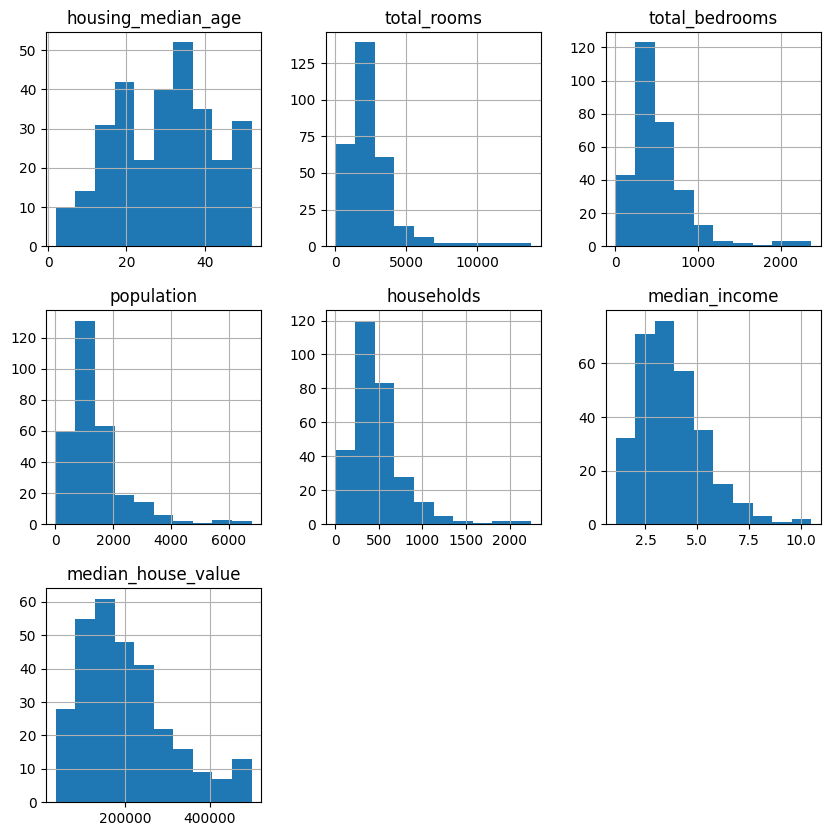

In [ ]:
data_sample[data_sample.columns].hist(figsize=(10,10))

## Hierarchical clustering
Performed hierarchical clustering using various linking methods. By creating dendrograms for each method to visualize and analyze clustering.

## **Single linkage**
Regarding the number of clusters, the single linkage method's dendrogram does not yield definitive results. With the majority of the data points, it forms one large cluster; with higher index values, multiple smaller clusters emerge.
## **Complete linkage**
Based on the data set, the dendrogram indicates the establishment of 3 separate clusters, each defined by a gap between its highest branch, which indicates a unique grouping feature.
## **Average Linkage**
According to the dendrogram, 3 or 4 clusters have formed, signifying 3 or 4 different groups with differing levels of subgroup similarity.
## **Ward**
Using Ward's approach, a dendrogram is created by splitting the data into 3 or 4 primary clusters. Significant gaps between the tallest branches, particularly those of blue and green, support this discovery and show that there are notable distinctions between these groupings.

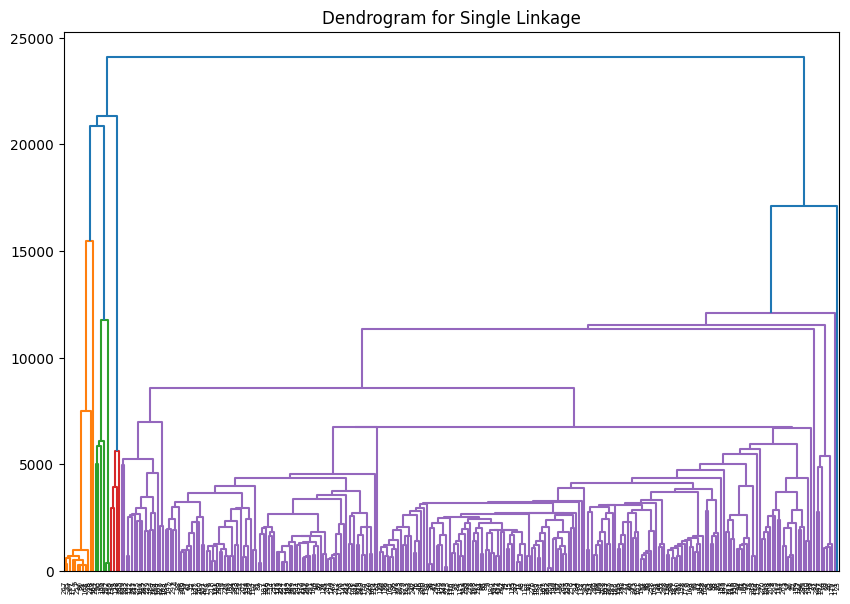

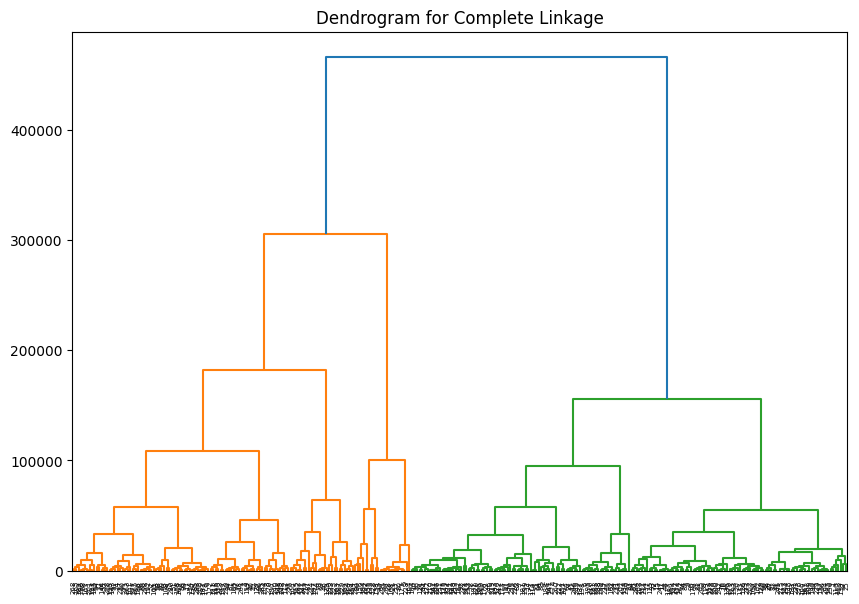

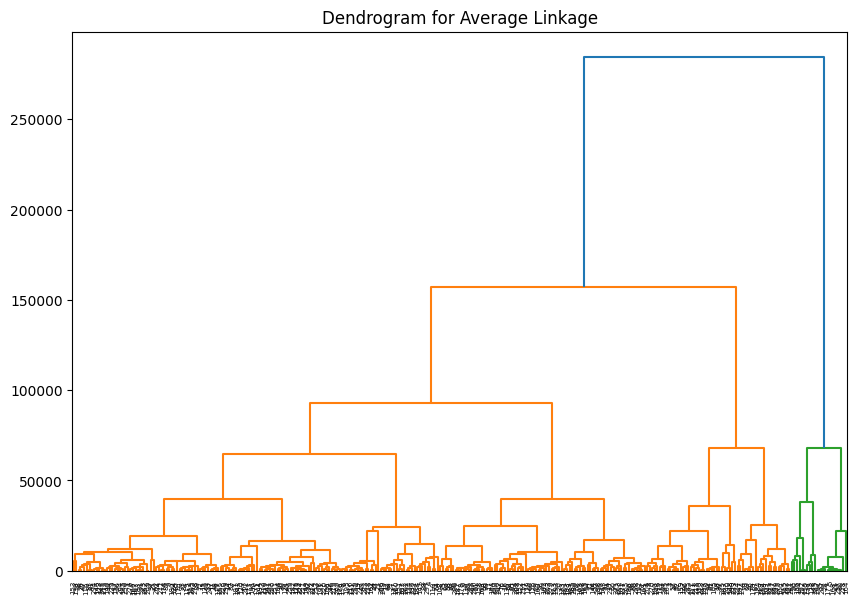

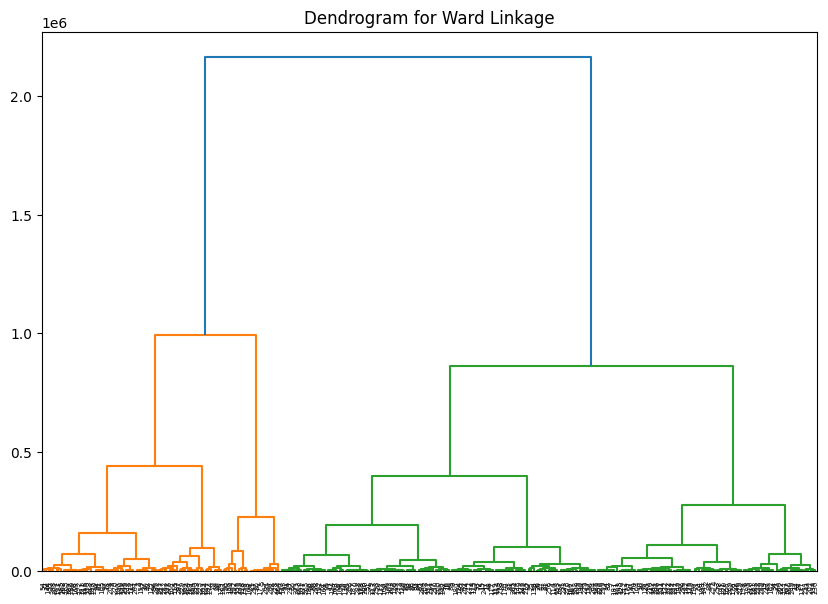

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Function to create dendrogram
def create_dendrogram(data, method, title):
    linked = linkage(data, method=method, metric='euclidean')
    plt.figure(figsize=(10, 7))
    dendrogram(linked,
               orientation='top',
               labels=data.index.tolist(),
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title(f'Dendrogram for {title} Linkage')
    plt.show()

# Creating dendrograms for each linkage method
linkage_methods = ['single', 'complete', 'average', 'ward']
for method in linkage_methods:
    create_dendrogram(data, method, method.capitalize())

Different cluster solutions are revealed by analysing dendrograms using the following linkage methods:
* Single linkage: Indicates a less distinct grouping, maybe consisting of many smaller groups inside a larger group.
* Complete Linkage: Displays approximately 3 major clusters.
* Average Linkage: Ward Linkage: consists approximately 3 or 4 separate clusters.
* Ward Linkage: Ward Linkage: consists of 3 to 4 separate clusters.

The findings demonstrate that a greater knowledge of clustering is provided by the Ward and Complete link approaches. We use **StandardScaler** to standardise the data and reassess the dendrograms in order to guarantee correctness and consistency. By subtracting the mean and scaling to the unit variance, this step helps in our understanding of how clusters arise.


## **Single (Standardized) linkage**
Single linkage dendrogram makes it challenging to discern distinct clusters without significant amounts of overlap. When taking higher thresholds into account, this approach could indicate two major clusters; nonetheless, it is evident that the boundaries between the groups are not clearly defined, making the clusters challenging to understand.
## **Complete (Standardized) linkage**
Complete linkage dendrograms show approximately 4-5 major clusters. The precise number of clusters, however, may differ based on the threshold level used.
## **Average (Standardized) linkage**
We are unable to get certain conclusions from the centroid dendrogram. A possible single dominant group is indicated by the way most of the data points appear to come together into a large cluster. Some clusters appear to be developing at larger distances, which might mean that smaller, different groupings are present. It is difficult to pinpoint the precise number of clusters—possibly 2 to 4—without a more precise threshold.
## **Ward (Standardized) linkage**
Depending on the minimum criterion applied, Ward's dendrogram offers the potential of forming 3 or 4 clusters. This visualisation makes it evident that there are multiple smaller clusters in addition to one very large one, showing that the data's features change significantly between different groups.

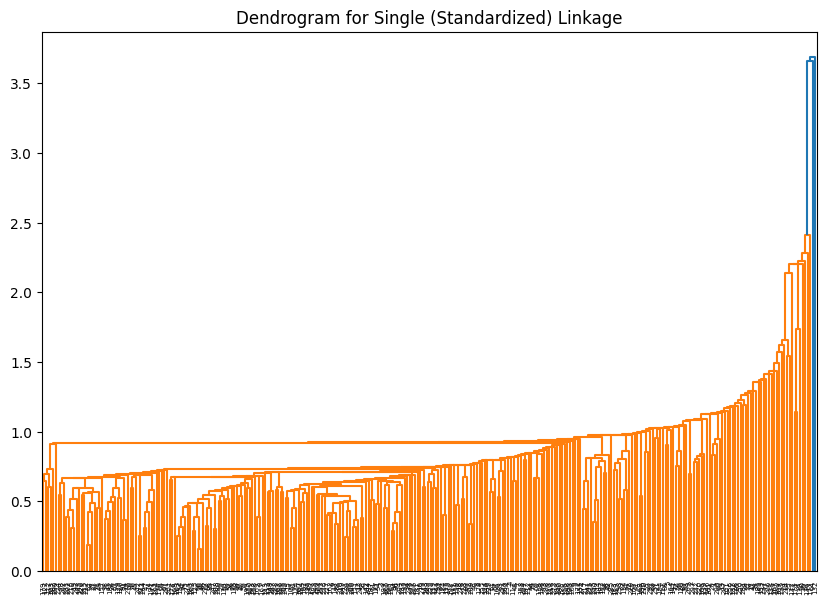

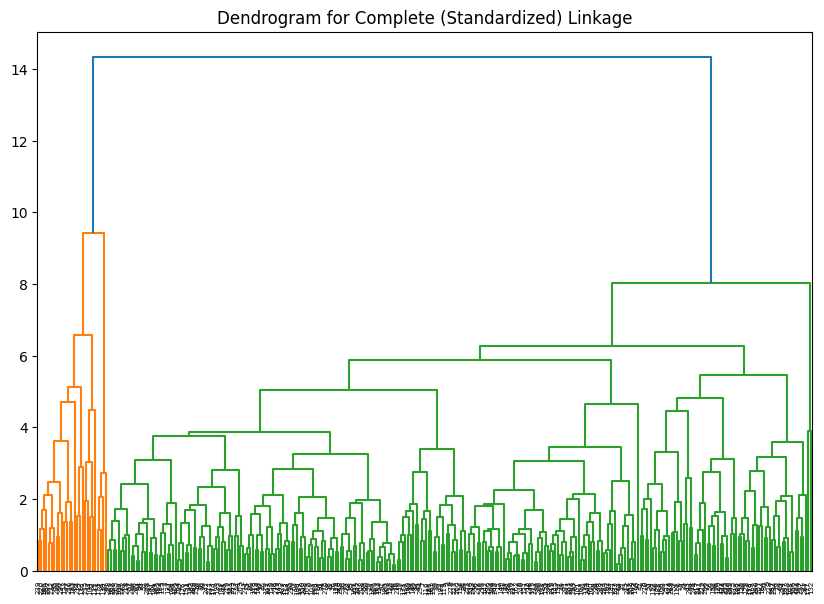

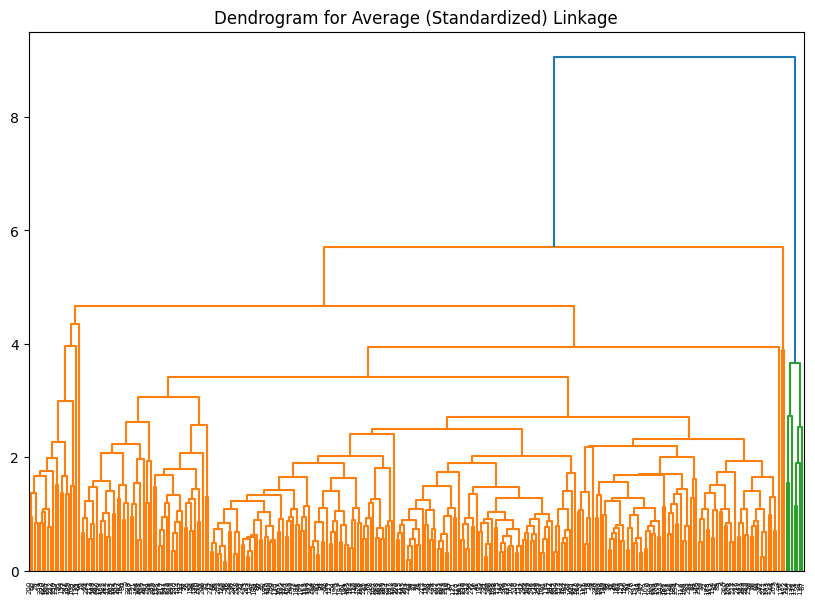

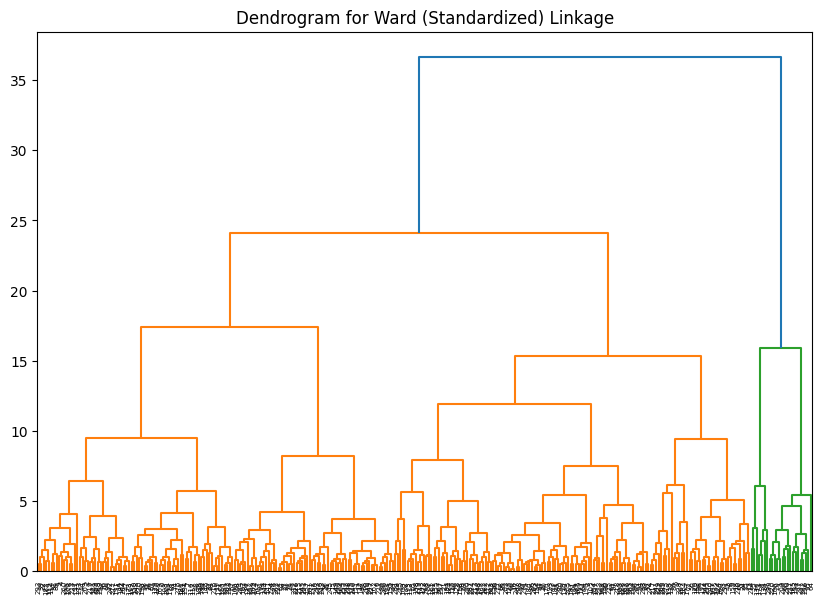

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardizing the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[feature_columns])

# Convert scaled data back to DataFrame for indexing purposes in dendrograms
data_scaled_df = pd.DataFrame(data_scaled, columns=feature_columns)

# Creating dendrograms for each linkage method on standardized data
for method in linkage_methods:
    create_dendrogram(data_scaled_df, method, method.capitalize() + ' (Standardized)')

In considering these results, it becomes sense to investigate and evaluate the cluster structures further by running K-means clustering calculations with 3, 4, and 5 clusters. This strategy will enable comparison analysis to identify the most significant data division.

## K-Means clustering on original-scale features

K-Means Clustering Results Analysis We applied k-means clustering to the standardized data with 3, 4, and 5 clusters. Here's a breakdown of the analysis for each scenario:

**3 Clusters Analysis:**
Cluster 1 consists of 146 observations with lower median house values and higher populations.
Cluster 2 contains 110 observations characterized by higher median incomes and house values.
Cluster 3 has 44 observations with the highest median incomes and house values, indicating a segment of more affluent areas.

**4 Clusters Analysis:**
The most populated cluster has lower median house values, while the smallest cluster has higher house values and median incomes, indicating more exclusive areas.

**5 Clusters Analysis:**
The distribution is segmented, with 90 observations focusing on moderate house values and incomes, and 22 observations with the highest median house values and incomes.


In [ ]:
from sklearn.cluster import KMeans

# Dropping non-feature columns safely
data_features = data[feature_columns].copy()

# Define a function to perform KMeans clustering and process results
def process_kmeans(n_clusters, data_features):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(data_features)
    cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=data_features.columns)
    cluster_counts = pd.Series(kmeans.labels_).value_counts()
    return cluster_centers, cluster_counts

# Performing K-Means clustering for 3, 4, and 5 clusters
results_3_clusters = process_kmeans(3, data_features)
results_4_clusters = process_kmeans(4, data_features)
results_5_clusters = process_kmeans(5, data_features)

# Print results to verify
print("Results for 3 Clusters without standardized data:")
print(results_3_clusters)
print("\nResults for 4 Clusters without standardized data:")
print(results_4_clusters)
print("\nResults for 5 Clusters without standardized data:")
print(results_5_clusters)

Results for 3 Clusters without standardized data:
(   housing_median_age  total_rooms  total_bedrooms   population  households  \
0           26.212329  2616.376712      544.986301  1518.705479  495.082192   
1           30.945455  2408.836364      510.681818  1397.963636  486.881818   
2           35.863636  2569.409091      492.977273  1072.181818  466.295455   

   median_income  median_house_value     cluster_3  cluster_4  cluster_5  \
0       3.025536       118658.219178  1.887379e-15   1.589041   1.150685   
1       4.051950       233350.000000  1.000000e+00   0.927273   2.863636   
2       5.440914       407629.772727  2.000000e+00   2.000000   2.000000   

   Cluster_3  Cluster_4  Cluster_5  
0   0.506849   1.253425   1.869863  
1   0.454545   1.181818   2.081818  
2   0.477273   1.045455   1.954545  , 0    146
1    110
2     44
Name: count, dtype: int64)

Results for 4 Clusters without standardized data:
(   housing_median_age  total_rooms  total_bedrooms   population  househo

## ANOVA across clusters
The ANOVA results reveal significant differences in variables across the California Housing dataset, categorized into 3, 4, and 5 clusters.

**3 Clusters:**
Strong differences are seen in median house value and total rooms, which suggests these variables strongly define the clusters.

**4 Clusters:**
Clearer differences, especially in housing characteristics like total rooms, total bedrooms, and households.

**5 Clusters:**
Increasing to 5 clusters highlights even more differences across all variables, especially economic factors like median house value and median income.

This analysis confirms the appropriateness of using 3 to 5 clusters for further detailed investigations.

In [ ]:
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.formula.api import ols

data_features = data[feature_columns].copy()

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(data_features)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(data_features)
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(data_features)

data_unscaled = data_features.copy()
data_unscaled['cluster_3'] = kmeans_3.labels_
data_unscaled['cluster_4'] = kmeans_4.labels_
data_unscaled['cluster_5'] = kmeans_5.labels_

def anova_for_clusters(frame, cluster_col):
    results = {}
    for column in feature_columns:
        model = ols(f'{column} ~ C({cluster_col})', data=frame).fit()
        results[column] = sm.stats.anova_lm(model, typ=2)
    return results

anova_results_3_clusters = anova_for_clusters(data_unscaled, 'cluster_3')
anova_results_4_clusters = anova_for_clusters(data_unscaled, 'cluster_4')
anova_results_5_clusters = anova_for_clusters(data_unscaled, 'cluster_5')

print('ANOVA Results for 3 Clusters:')
print(anova_results_3_clusters)
print('\nANOVA Results for 4 Clusters:')
print(anova_results_4_clusters)
print('\nANOVA Results for 5 Clusters:')
print(anova_results_5_clusters)

The graphs reveal that as the number of clusters increases, specific characteristics become more apparent, providing a more comprehensive understanding of market structure.

In [ ]:
import seaborn as sns
def plot_boxplots(data, cluster_label):
        num_variables = len(data.columns) - 1  # Adjust for columns count
        fig, axs = plt.subplots(nrows=1, ncols=num_variables, figsize=(num_variables * 5, 6), sharey=True)
        for i, column in enumerate(data.columns[:-1]):  # Exclude cluster label column
            if column != cluster_label:
                sns.boxplot(x=cluster_label, y=column, data=data, ax=axs[i])
                axs[i].set_title(f'Boxplot of {column} by {cluster_label}')
                axs[i].set_xlabel('Cluster')
                axs[i].set_ylabel(column)
        plt.subplots_adjust(wspace=0.5)  # Adjust the space between subplots
        plt.tight_layout()
        plt.show()

# Print ANOVA results and plot boxplots
print("ANOVA Results for 3 Clusters:")
plot_boxplots(data_unscaled, 'cluster_3')

print("\nANOVA Results for 4 Clusters:")
plot_boxplots(data_unscaled, 'cluster_4')

print("\nANOVA Results for 5 Clusters:")
plot_boxplots(data_unscaled, 'cluster_5')

## K-Means clustering on original-scale features with standardized data

K-Means Clustering Results Analysis
We applied k-means clustering to the standardized data with 3, 4, and 5 clusters. Here's a breakdown of the analysis for each scenario:

**3 Clusters:**

Cluster Sizes: Cluster 1: 162, Cluster 0: 110, Cluster 2: 28

Cluster Centers:

Cluster 0: Older housing, moderately sized population, and high median income and house values.

Cluster 1: Median age housing, smaller populations and households, lowest median income and house values.

Cluster 2: Youngest housing, largest rooms and populations, moderate income, higher house values.

**4 Clusters:**

Cluster Sizes: Cluster 0: 118, Cluster 3: 96, Cluster 1: 78, Cluster 2: 8

Cluster Centers:

Cluster 0: Older median housing, smallest rooms and population, lowest median income and house values.

Cluster 1: Younger median age housing, large rooms and population, moderate income and house values.

Cluster 2: Very young median age, extremely large rooms and population, highest income and house values.

Cluster 3: Oldest housing, moderate rooms and population, highest income and house values.

**5 Clusters:**

Cluster Sizes: Cluster 2: 102, Cluster 4: 77, Cluster 0: 60, Cluster 1: 53, Cluster 3: 8

Cluster Centers:

Cluster 0: Median age housing, moderate rooms and population, very high median income and house values.

Cluster 1: Young housing, largest rooms and population, moderate income, moderate house values.

Cluster 2: Older housing, smaller rooms and population, moderate income, slightly higher house values.

Cluster 3: Very young housing, extremely large rooms and population, highest income and house values.

Cluster 4: Young housing, smaller rooms and population, lower income and house values.

The four clusters appear to have achieved a decent compromise between significant segmentation and level of detail, avoiding unnecessary details.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Dropping non-feature columns safely
data_features = data[feature_columns].copy()

# Initialize the scaler and transform data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_features)

# Define a function to perform KMeans clustering and process results
def process_kmeans(n_clusters, data_scaled, data_features_columns):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=data_features_columns)
    cluster_counts = pd.Series(kmeans.labels_).value_counts()
    return cluster_centers, cluster_counts

# Performing K-Means clustering for 3, 4, and 5 clusters
results_3_clusters = process_kmeans(3, data_scaled, data_features.columns)
results_4_clusters = process_kmeans(4, data_scaled, data_features.columns)
results_5_clusters = process_kmeans(5, data_scaled, data_features.columns)

# Print results to verify
print("Results for 3 Clusters with standardized data:")
print(results_3_clusters)
print("\nResults for 4 Clusters with standardized data:")
print(results_4_clusters)
print("\nResults for 5 Clusters with standardized data:")
print(results_5_clusters)

Results for 3 Clusters with standardized data:
(   housing_median_age  total_rooms  total_bedrooms   population   households  \
0           33.475000  2231.866667      447.383333  1097.216667   426.483333   
1           28.437908  1967.392157      435.464052  1246.973856   402.830065   
2           16.333333  7080.814815     1374.888889  3712.222222  1242.407407   

   median_income  median_house_value  cluster_3  cluster_4  cluster_5  \
0       4.728839       305210.916667   1.341667   1.550000   3.158333   
1       2.971820       128618.300654   0.156863   1.320261   1.019608   
2       3.877548       171274.074074   0.481481   1.259259   1.333333   

   Cluster_3  Cluster_4  Cluster_5  
0   0.391667   1.041667   2.033333  
1   0.366013   1.091503   1.849673  
2   1.555556   2.481481   2.259259  , 1    153
0    120
2     27
Name: count, dtype: int64)

Results for 4 Clusters with standardized data:
(   housing_median_age  total_rooms  total_bedrooms   population   households  \
0     

## ANOVA across clusters with standardized data

Using standardised data, ANOVA results for clusters 3, 4, and 5 show that as the number of clusters grows, so do the disparities across groups, particularly with regard to housing features and economic status. Important characteristics like **total rooms** and **median house_value** change significantly at each cluster level, highlighting the volatility of the housing market.

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Dropping non-feature columns safely
data_features = data[feature_columns].copy()

# Scaling data - assuming you want to perform clustering on scaled data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_features)
data_scaled_df = pd.DataFrame(data_scaled, columns=data_features.columns)

# Performing k-means clustering for 3, 4, and 5 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(data_scaled_df)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(data_scaled_df)
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(data_scaled_df)

# Assigning cluster labels to the dataframe
data_scaled_df['cluster_3'] = kmeans_3.labels_
data_scaled_df['cluster_4'] = kmeans_4.labels_
data_scaled_df['cluster_5'] = kmeans_5.labels_

# Define a function to perform ANOVA based on cluster labels
def anova_for_clusters(data, cluster_col):
    anova_results = {}
    for column in feature_columns:
        if pd.api.types.is_numeric_dtype(data[column]):  # Ensure column is numeric for ANOVA
            model = ols(f'{column} ~ C({cluster_col})', data=data).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            anova_results[column] = anova_table
    return anova_results

# Conducting ANOVA for each set of clusters
anova_results_3_clusters = anova_for_clusters(data_scaled_df, 'cluster_3')
anova_results_4_clusters = anova_for_clusters(data_scaled_df, 'cluster_4')
anova_results_5_clusters = anova_for_clusters(data_scaled_df, 'cluster_5')

# Print ANOVA results to verify
print("ANOVA Results for 3 Clusters with standardized data:")
print(anova_results_3_clusters)
print("\nANOVA Results for 4 Clusters with standardized data:")
print(anova_results_4_clusters)
print("\nANOVA Results for 5 Clusters with standardized data:")
print(anova_results_5_clusters)

The diagrams in clusters 3, 4 and 5 show growing differentiation in key housing characteristics, and confirm the ANOVA results

Boxplots for 3 Clusters:


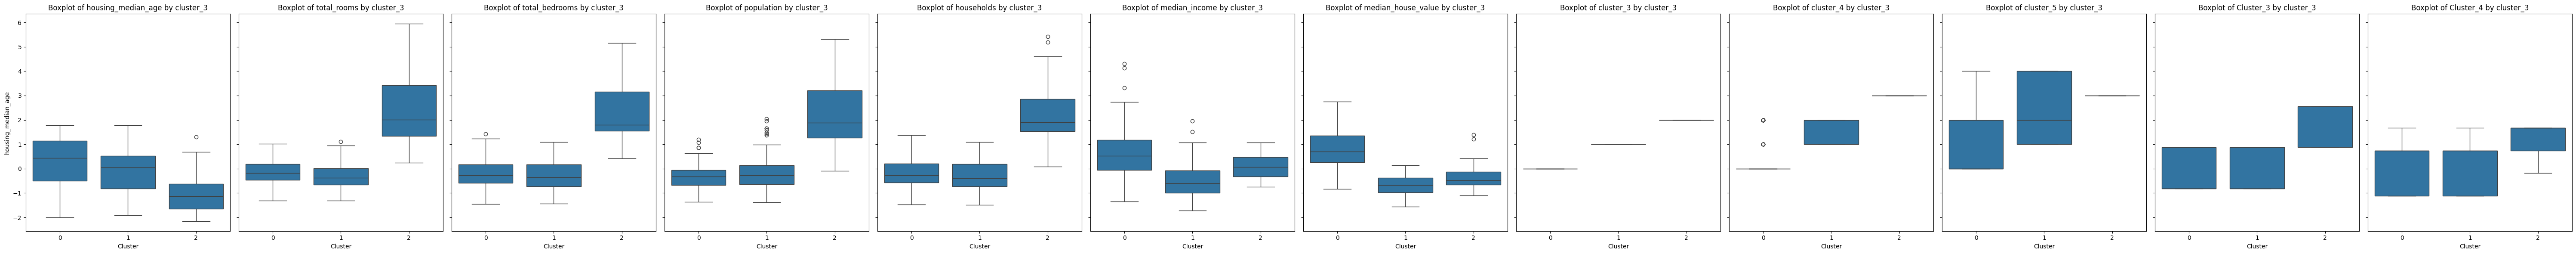

Boxplots for 4 Clusters:


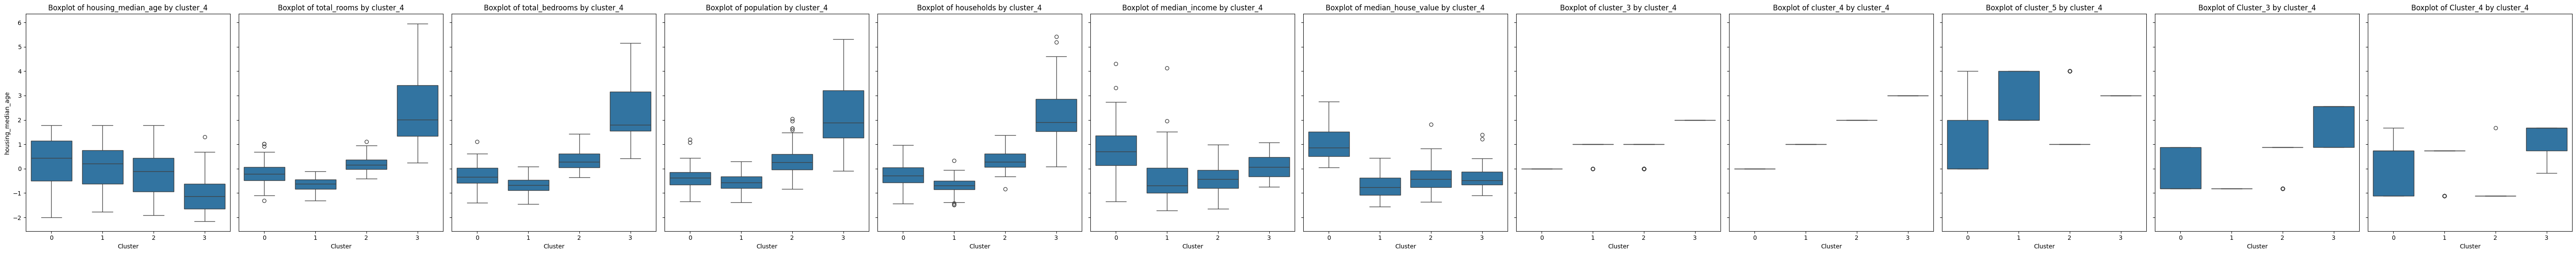

Boxplots for 5 Clusters:


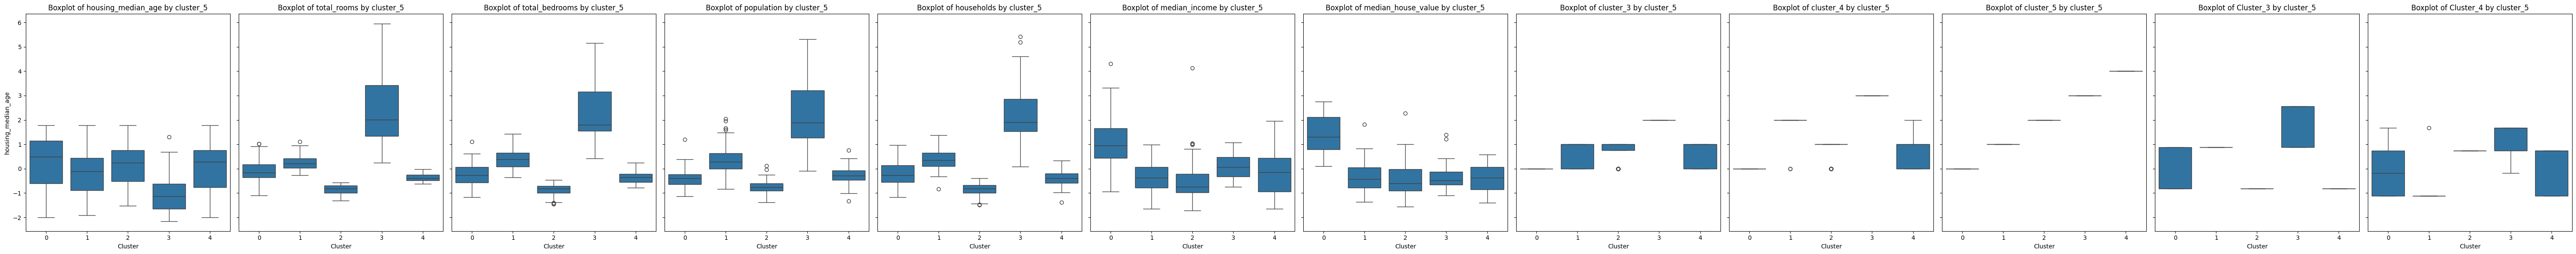

In [ ]:
def plot_boxplots(data, cluster_label):
    # Set the number of subplot columns
    num_variables = data.shape[1] - 1  # excluding the cluster label column
    fig, axs = plt.subplots(nrows=1, ncols=num_variables, figsize=(num_variables * 5, 6), sharey=True)

    for i, column in enumerate(data.columns[:-1]):  # exclude the cluster label column
        sns.boxplot(x=cluster_label, y=column, data=data, ax=axs[i])
        axs[i].set_title(f'Boxplot of {column} by {cluster_label}')
        axs[i].set_xlabel('Cluster')
        axs[i].set_ylabel(column)

    plt.tight_layout()
    plt.show()

# Create boxplots for each clustering result
print("Boxplots for 3 Clusters:")
plot_boxplots(data_scaled_df, 'cluster_3')

print("Boxplots for 4 Clusters:")
plot_boxplots(data_scaled_df, 'cluster_4')

print("Boxplots for 5 Clusters:")
plot_boxplots(data_scaled_df, 'cluster_5')

A silhouette plot is created to show the degree to which a point fits its cluster relative to other clusters. The results show that two clusters is the ideal number of clusters. Subsequent Analyzes 3 and 5 appear to fit the data most closely, more closely fitting our findings.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
# Function to perform clustering and store labels
def get_cluster_labels(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    return labels

# Range of clusters to evaluate
cluster_range = range(2, 11)  # For example, from 2 to 10 clusters

# Dictionary to hold labels for each cluster count
cluster_labels = {n: get_cluster_labels(data_scaled_df[feature_columns], n) for n in cluster_range}

# Function to plot silhouette scores
def plot_silhouette_scores(data_scaled_df[feature_columns], cluster_labels):
    range_n_clusters = sorted(cluster_labels.keys())  # Sorted list of cluster counts
    silhouette_avg_scores = []  # To store average silhouette scores

    for n_clusters in range_n_clusters:
        labels = cluster_labels[n_clusters]
        silhouette_avg = silhouette_score(data, labels)
        silhouette_avg_scores.append(silhouette_avg)

        # Display the silhouette score for each number of clusters
        print(f"Number of clusters = {n_clusters}: Silhouette Score = {silhouette_avg:.3f}")

    # Plotting the average silhouette scores for each cluster count
    plt.figure(figsize=(10, 6))
    plt.plot(range_n_clusters, silhouette_avg_scores, marker='o')
    plt.title("Silhouette Score for Different Numbers of Clusters")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Average Silhouette Score")
    plt.grid(True)
    plt.show()

# Call the function to plot silhouette scores
plot_silhouette_scores(data_scaled_df[feature_columns], cluster_labels)

## Elbow method

The elbow plot identifies the optimal number of clusters based on the l-oct point, suggesting 3 three clusters are most effective for dividing a data set due to diminishing returns from reducing within-cluster variance.

In [ ]:
from kneed import KneeLocator
# Range of potential clusters
range_clusters = range(1, 11)  # Typically 1 to 10 clusters

# Calculate WCSS (within-cluster sums of squares) for each number of clusters
wcss = []
for n_clusters in range_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled_df[feature_columns])
    wcss.append(kmeans.inertia_)  # Inertia: Sum of squared distances of samples to their closest cluster center

# Plotting the results onto a line graph to observe 'The Elbow'
plt.figure(figsize=(10, 6))
plt.plot(range_clusters, wcss, 'bo-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')  # Within cluster sum of squares
plt.grid(True)

# Using KneeLocator to find the elbow point
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
print("Elbow point at:", kl.elbow)  # This prints out the optimal number of clusters according to KneeLocator

# Mark the knee point on the plot
plt.vlines(kl.elbow, plt.ylim()[0], plt.ylim()[1], linestyles='dashed')
plt.show()

In [ ]:
kl.elbow #how many claster do we have

3


The descriptive statistics across four clusters of standardized housing data reveal distinct housing market segments:

Cluster 0: Middle-class neighborhoods with moderate amenities.

Cluster 1: Low-income neighborhoods with smaller homes.

Cluster 2: New areas with recent development.

Cluster 3: Mixed areas with old houses and different economic levels.

In [ ]:
# Assigning the selected 4-cluster labels for easier reference
data_scaled_df['cluster'] = data_scaled_df['cluster_4']

# Calculating descriptive statistics for each cluster
cluster_descriptive_stats = data_scaled_df.groupby('cluster').describe()

# Displaying descriptive statistics for key variables for each cluster
key_variables = ['housing_median_age', 'total_rooms', 'population', 'median_income', 'median_house_value']
cluster_descriptive_stats[key_variables]

housing_median_age                                                    \
                     count      mean       std       min       25%       50%   
cluster                                                                        
0                     95.0  0.359983  1.038188 -1.996362 -0.500862  0.443665   
1                     95.0  0.123852  0.867551 -1.760230 -0.618927  0.207534   
2                     83.0 -0.220159  0.872440 -1.917652 -0.933770 -0.107309   
3                     27.0 -1.025599  0.862231 -2.153783 -1.642165 -1.130546   

                            total_rooms            ... median_income  \
              75%       max       count      mean  ...           75%   
cluster                                            ...                 
0        1.152060  1.781745        95.0 -0.197156  ...      1.360555   
1        0.758507  1.781745        95.0 -0.652890  ...      0.035900   
2        0.443665  1.781745        83.0  0.192190  ...     -0.063507   
3       -0.618927  1.309481        27.0  2.400094  ...      0.473980   

                  median_house_value                                          \
              max              count      mean       std       min       25%   
cluster                                                                        
0        4.298849               95.0  1.116678  0.839258  0.049026  0.513821   
1        4.121693               95.0 -0.702144  0.459442 -1.556963 -1.075998   
2        0.979457               83.0 -0.378817  0.546611 -1.368458 -0.761823   
3        1.078577               27.0 -0.294034  0.617235 -1.095865 -0.660640   

                                       
              50%       75%       max  
cluster                                
0        0.861262  1.509479  2.743549  
1       -0.761361 -0.375110  0.433429  
2       -0.418540 -0.079878  1.819496  
3       -0.486919 -0.134396  1.397207  

[4 rows x 40 columns]

Scatterplots show how clusters vary by economic status and housing density, with higher income clusters showing higher home values and denser clusters having more rooms, indicating different segments in the market.

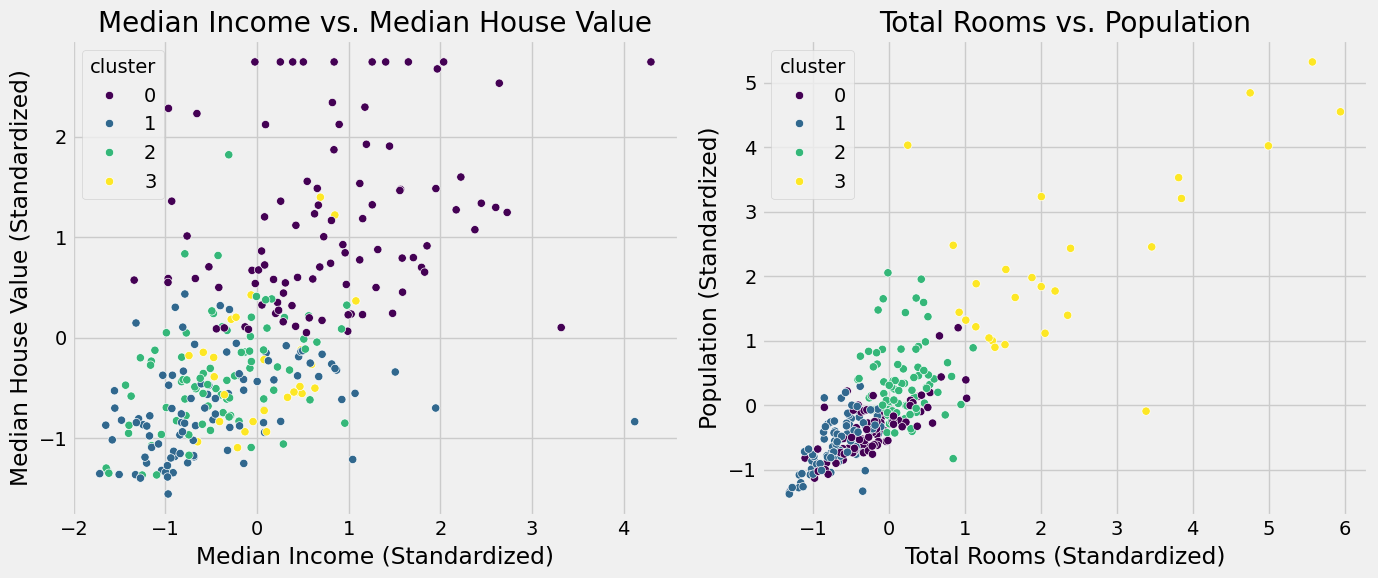

In [ ]:
import seaborn as sns

# Setting up the matplotlib figure
plt.figure(figsize=(14, 6))

# Plotting Median Income vs. Median House Value
plt.subplot(1, 2, 1)
sns.scatterplot(x='median_income', y='median_house_value', hue='cluster', data=data_scaled_df, palette='viridis', legend='full')
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income (Standardized)')
plt.ylabel('Median House Value (Standardized)')

# Plotting Total Rooms vs. Population
plt.subplot(1, 2, 2)
sns.scatterplot(x='total_rooms', y='population', hue='cluster', data=data_scaled_df, palette='viridis', legend='full')
plt.title('Total Rooms vs. Population')
plt.xlabel('Total Rooms (Standardized)')
plt.ylabel('Population (Standardized)')

plt.tight_layout()
plt.show()

## Conclusion

The clustering methods provide complementary views of the data rather than one single answer. Hierarchical clustering suggested several plausible groupings, while the Elbow and Silhouette criteria favoured different solutions. For portfolio demonstration, the notebook profiles a four-cluster solution because it provides interpretable differentiation across housing and economic characteristics.

The main lesson is that cluster selection should combine statistical diagnostics with interpretability and the analytical purpose of the segmentation.